## TFIDF + Logistic Regression + SMOTE

📥 Downloading dataset from Kaggle...
Dataset shape: (58856, 4)
Label distribution:
sentiment_label
positive    57333
negative      771
neutral       752
Name: count, dtype: int64

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Train distribution BEFORE SMOTE:
  negative: 617
  neutral: 601
  positive: 45866

TF-IDF shape: (47084, 5000)

Train distribution AFTER SMOTE:
  negative: 45866
  neutral: 45866
  positive: 45866


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



✅ Model training completed!

EVALUATION RESULT - MODEL 2 (SMOTE)
Accuracy  : 0.9278
Macro F1  : 0.4994

Classification Report:
              precision    recall  f1-score   support

    negative       0.23      0.60      0.33       154
     neutral       0.13      0.47      0.20       151
    positive       1.00      0.94      0.97     11467

    accuracy                           0.93     11772
   macro avg       0.45      0.67      0.50     11772
weighted avg       0.97      0.93      0.95     11772



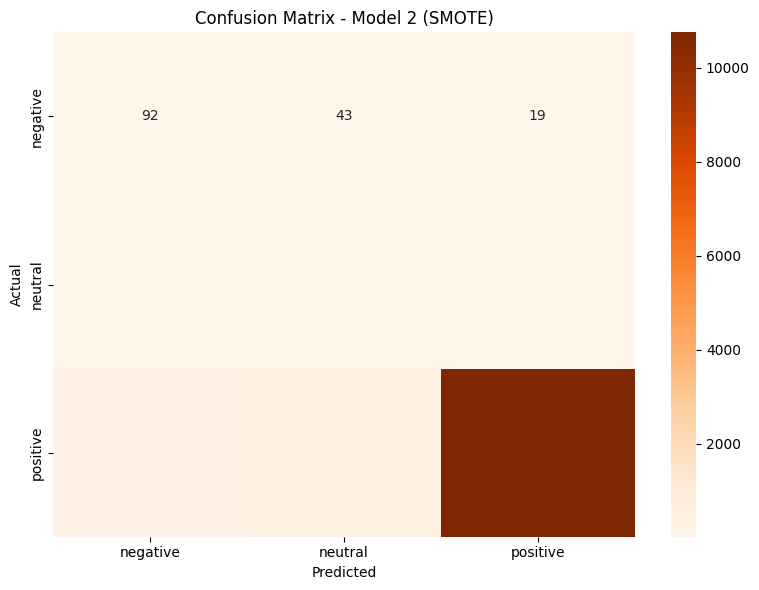


PER-CLASS METRICS
negative   | P: 0.2312 | R: 0.5974 | F1: 0.3333 | Support: 154
neutral    | P: 0.1261 | R: 0.4702 | F1: 0.1989 | Support: 151
positive   | P: 0.9952 | R: 0.9383 | F1: 0.9659 | Support: 11467

CUSTOM PREDICTIONS
Review: barang bagus banget pengiriman cepat
Predicted: positive

Review: produk jelek dan rusak parah kecewa
Predicted: negative

Review: lumayan sesuai harga standar
Predicted: neutral



In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns   
import kagglehub
import os


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# ============================================================
# 1. LOAD & PREPROCESS DATA
# ============================================================
# 4. LOAD DATA DARI KAGGLE
print("📥 Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("salmanabdu/tokopedia-product-reviews-2025")
file_path = os.path.join(path, 'tokopedia_product_reviews_2025.csv')

df = pd.read_csv(file_path)
df = df[['review_text', 'sentiment_label']].copy()
df.dropna(inplace=True)

# Filter review terlalu pendek (< 3 kata)
df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 3]

# Text preprocessing
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\\S+|www\\S+', '', text)
    text = re.sub(r'@\\w+', '', text)
    text = re.sub(r'&\\w+;', '', text)
    text = re.sub(r'\\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review_text'].apply(clean_text)
df = df[df['clean_review'].str.len() > 0]

print("Dataset shape:", df.shape)
print("Label distribution:")
print(df['sentiment_label'].value_counts())

# ============================================================
# 2. ENCODE LABELS
# ============================================================
le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment_label'])
print("\nLabel mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================
X = df['clean_review']
y = y_encoded

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTrain distribution BEFORE SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for i, count in enumerate(counts):
    print(f"  {le.inverse_transform([i])[0]}: {count}")

# ============================================================
# 4. TF-IDF VECTORIZATION
# ============================================================
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF shape: {X_train_tfidf.shape}")

# ============================================================
# 5. SMOTE OVERSAMPLING
# ============================================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print("\nTrain distribution AFTER SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for i, count in enumerate(counts):
    print(f"  {le.inverse_transform([i])[0]}: {count}")

# ============================================================
# 6. TRAIN LOGISTIC REGRESSION
# NOTE: TANPA class_weight karena SMOTE sudah balance data
# ============================================================
model = LogisticRegression(
    solver='lbfgs',
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_smote, y_train_smote)
print("\n✅ Model training completed!")

# ============================================================
# 7. EVALUATION
# ============================================================
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n" + "="*50)
print("EVALUATION RESULT - MODEL 2 (SMOTE)")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Macro F1  : {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Model 2 (SMOTE)")
plt.tight_layout()
plt.savefig('confusion_matrix_model2.png', dpi=150)
plt.show()

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)
print("\n" + "="*50)
print("PER-CLASS METRICS")
print("="*50)
for i, cls in enumerate(le.classes_):
    print(f"{cls:<10} | P: {precision[i]:.4f} | R: {recall[i]:.4f} | F1: {f1[i]:.4f} | Support: {support[i]}")

# ============================================================
# 8. TEST CUSTOM INPUT
# ============================================================
sample_reviews = [
    "barang bagus banget pengiriman cepat",
    "produk jelek dan rusak parah kecewa",
    "lumayan sesuai harga standar"
]

sample_clean = [clean_text(x) for x in sample_reviews]
sample_vector = tfidf.transform(sample_clean)
sample_pred = model.predict(sample_vector)
sample_pred_labels = le.inverse_transform(sample_pred)

print("\n" + "="*50)
print("CUSTOM PREDICTIONS")
print("="*50)
for review, pred in zip(sample_reviews, sample_pred_labels):
    print(f"Review: {review}")
    print(f"Predicted: {pred}\n")
